# Exploratory Analysis of Daily Burned Area in Spain (1983–2022)

This notebook presents an exploratory analysis of a high-resolution spatial-temporal database on wildfires in Spain, spanning from January 2, 1983 to January 1, 2022. The database contains daily burned area estimates derived from satellite data and processed through the `climate4R` framework. The analysis is conducted using tools developed by the Santander Meteorology Group, an interdisciplinary research team from CSIC and Universidad de Cantabria, specializing in climate variability, downscaling and climate services.

The notebook showcases simple but informative calculations to demonstrate the capabilities of the dataset and the climate4R ecosystem. The analysis includes spatial statistics, temporal trends, and spatial upscaling of burned area data. The goal is to provide a quick yet comprehensive overview of the potential of this dataset for fire-related research and spatial analysis.

All steps are fully reproducible using `loadeR`, `transformeR`, and `visualizeR` packages.


In [9]:
library("loadeR")
library('transformeR')
library('visualizeR')

Cargando paquete requerido: rJava

Cargando paquete requerido: loadeR.java

Java version 1.8x amd64 by Oracle Corporation detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Cargando paquete requerido: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.2 (2024-06-04) is loaded

Please use 'citation("loadeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



## Data Extraction

We start by loading the burned area dataset using `loadGridData` from the `loadeR` package. The result is a gridC4R object, which contains daily burned area data over Spain at a spatial resolution of 0.25 degrees.

In [11]:
temp_dir <- tempdir()
temp_nc <- file.path(temp_dir, "fireData.nc")

url <- "https://zenodo.org/records/14644902/files/firespain025_WGS84_v0.nc?download=1"

download.file(url, temp_nc, mode = "wb")

grid_data <- loadGridData(temp_nc, var = 'ba')

[2025-07-29 15:05:15.989275] Defining geo-location parameters

[2025-07-29 15:05:16.082147] Defining time selection parameters

[2025-07-29 15:05:16.326215] Retrieving data subset ...

[2025-07-29 15:05:21.145997] Done



## Spatial Statistics Computation

In this section, we compute basic spatial statistics over the entire time period. These aggregated values help summarize key characteristics of the burned area dataset and are visualized as spatial climatologies.

### Mean Burned Area

Here, we compute the mean burned area per day at each pixel across the full time range. This highlights areas with recurrent or high-intensity fires.


[2025-06-16 13:41:59.164323] Performing annual aggregation...

[2025-06-16 13:42:04.714848] Done.

[2025-06-16 13:42:04.736114] - Computing climatology...

[2025-06-16 13:42:04.782307] - Done.



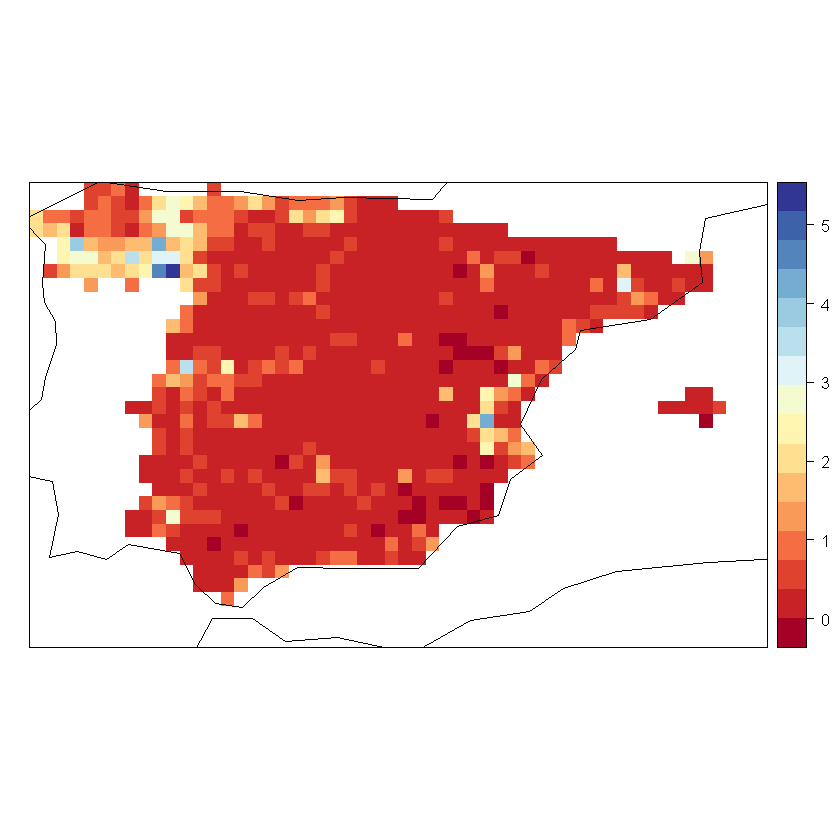

In [3]:
ba_grid_025_agg <- aggregateGrid(grid = grid_data, aggr.y = list(FUN = 'mean', na.rm = FALSE))
spatialPlot(climatology(ba_grid_025_agg), backdrop.theme = 'coastline')

### Total Wildfire Counts

Next, we compute the total number of wildfire events per pixel by counting the number of non-zero values over time. This provides insight into fire frequency.

[2025-06-16 13:42:52.466793] Performing annual aggregation...

[2025-06-16 13:42:53.971072] Done.

[2025-06-16 13:42:53.987994] - Computing climatology...

[2025-06-16 13:42:54.008029] - Done.



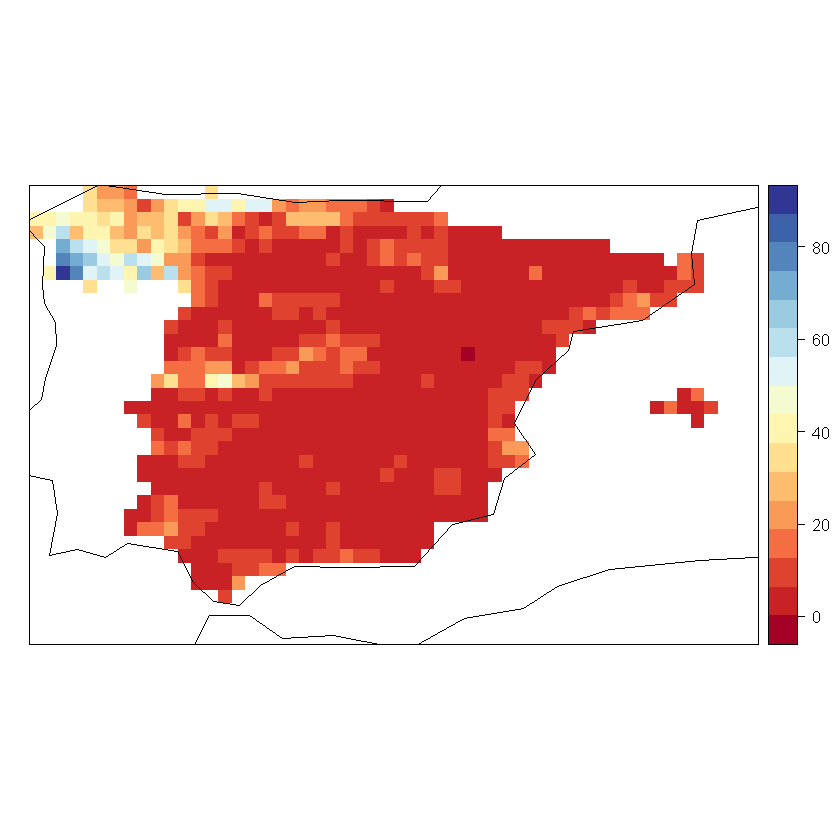

In [4]:
ba_grid_025_agg <- aggregateGrid(grid = grid_data, aggr.y = list(FUN = function(x) sum(x > 0, na.rm = FALSE)))
spatialPlot(climatology(ba_grid_025_agg), backdrop.theme = 'coastline')

### Wildfire Relative Frequency

We calculate the relative frequency of wildfires at each pixel, expressed as the ratio of days with fire occurrence to the total number of days. This metric gives a normalized measure of fire recurrence.


[2025-06-16 13:43:00.500153] Performing annual aggregation...

[2025-06-16 13:43:02.475896] Done.

[2025-06-16 13:43:02.495717] - Computing climatology...

[2025-06-16 13:43:02.518095] - Done.



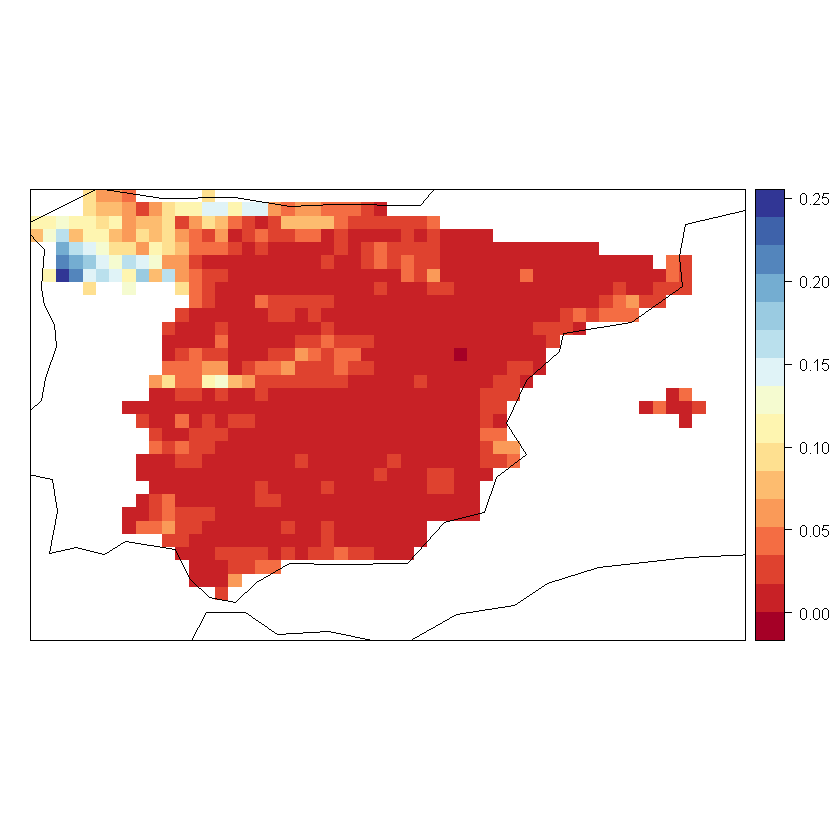

In [5]:
ba_grid_025_agg <- aggregateGrid(grid = grid_data, aggr.y = list(FUN = function(x) mean(x > 0, na.rm = FALSE)))
spatialPlot(climatology(ba_grid_025_agg), backdrop.theme = 'coastline')

## Temporal Evolution of Burned Area

This section focuses on the temporal dynamics of burned area. We explore how the area burned by wildfires evolves over time at both local and national scales.

### Pixel-Level Time Series

We extract and plot the time series of a single pixel located in Galicia, a region known for frequent wildfire activity. This illustrates how burned area varies locally across the decades.

In [8]:
subGridPixel <- subsetSpatial(grid_data,lonLim = -8.135,  latLim = 42.351L)

In [59]:
temporalSerie <- data.frame(
  date = as.Date(subGridPixel$Dates$start),
  ba = as.vector(subGridPixel$Data)
)

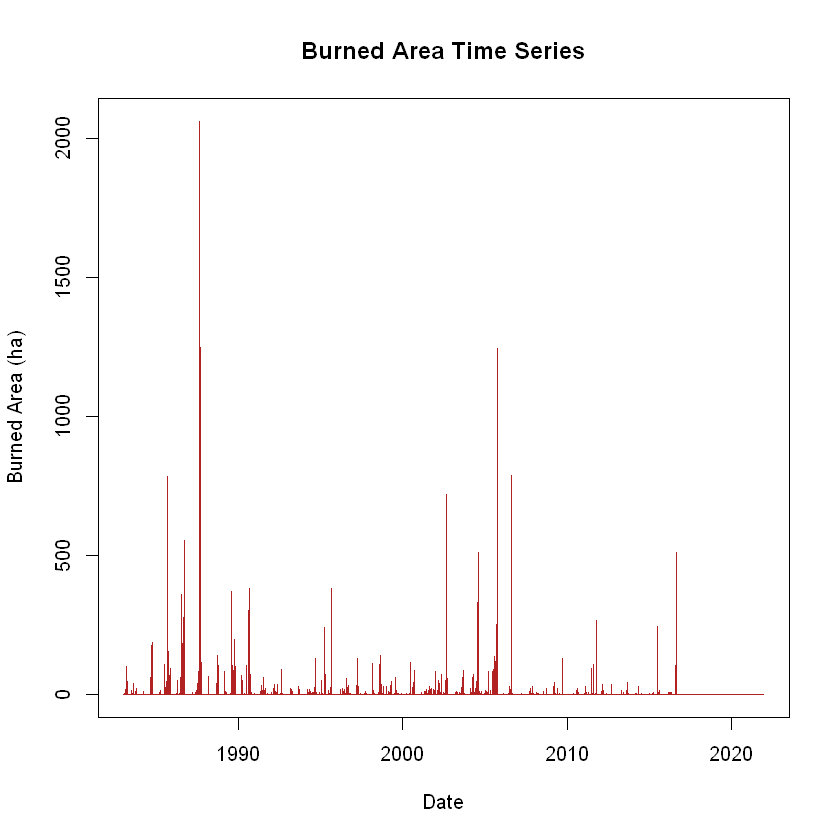

In [63]:
plot(
  temporalSerie$date,
  temporalSerie$ba,
  type = "l",
  col = "firebrick",
  xlab = "Date",
  ylab = "Burned Area (ha)",
  main = "Burned Area Time Series"
)

### National Time Series

We compute the total burned area in Spain per day by summing all pixels. The resulting time series reveals long-term trends, seasonality, and interannual variability in wildfire activity.


In [6]:
temporalSerie_spain <- aggregateGrid(grid_data, aggr.lat = list(FUN = "sum", na.rm = FALSE), aggr.lon = list(FUN = "sum", na.rm = FALSE))
temporalSerie_spain_df <- data.frame(
  date = as.Date(temporalSerie_spain$Dates$start),
  ba = as.vector(temporalSerie_spain$Data)
)

Calculating areal weights...

[2025-06-16 13:43:23.76984] - Aggregating lat dimension...

[2025-06-16 13:43:25.889444] - Done.

[2025-06-16 13:43:25.891823] - Aggregating lon dimension...

[2025-06-16 13:43:25.929375] - Done.



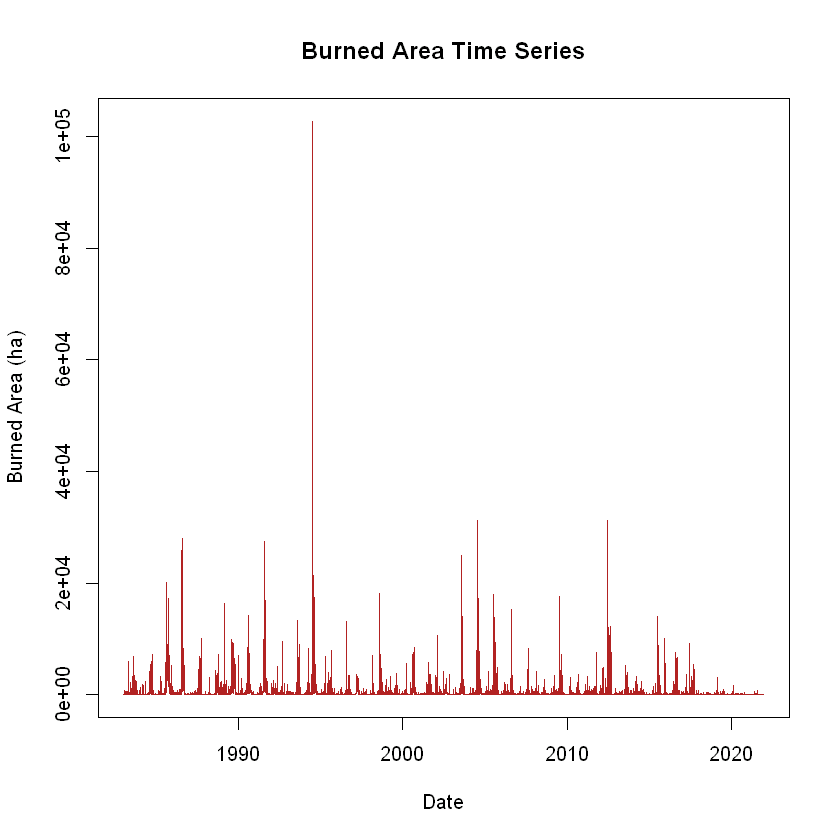

In [7]:
plot(
  temporalSerie_spain_df$date,
  temporalSerie_spain_df$ba,
  type = "l",
  col = "firebrick",
  xlab = "Date",
  ylab = "Burned Area (ha)",
  main = "Burned Area Time Series"
)

## Spatial Upscaling

Finally, we perform spatial upscaling of the original 0.25° grid to coarser resolutions (0.5°, 1°, and 1.5°) using the `upscaleGrid` function. We apply the sum function to preserve total burned area values. We then visualize each upscaled version using mean climatologies to compare the impact of spatial resolution on the data representation.

In [4]:
ba_grid_05 <- upscaleGrid(grid = grid_data, times = 2, aggr.fun = list(FUN = sum, na.rm = FALSE))

In [5]:
ba_grid_025_agg <- aggregateGrid(grid = grid_data, aggr.y = list(FUN = 'mean', na.rm = FALSE))
ba_grid_05_agg <- aggregateGrid(grid = ba_grid_05, aggr.y = list(FUN = 'mean', na.rm = FALSE))

[2025-06-19 12:26:50.249222] Performing annual aggregation...

[2025-06-19 12:26:55.61031] Done.

[2025-06-19 12:26:55.803966] Performing annual aggregation...

[2025-06-19 12:26:57.355344] Done.



[2025-06-19 12:26:57.400621] - Computing climatology...

[2025-06-19 12:26:57.422935] - Done.

[2025-06-19 12:26:57.69102] - Computing climatology...

[2025-06-19 12:26:57.723415] - Done.



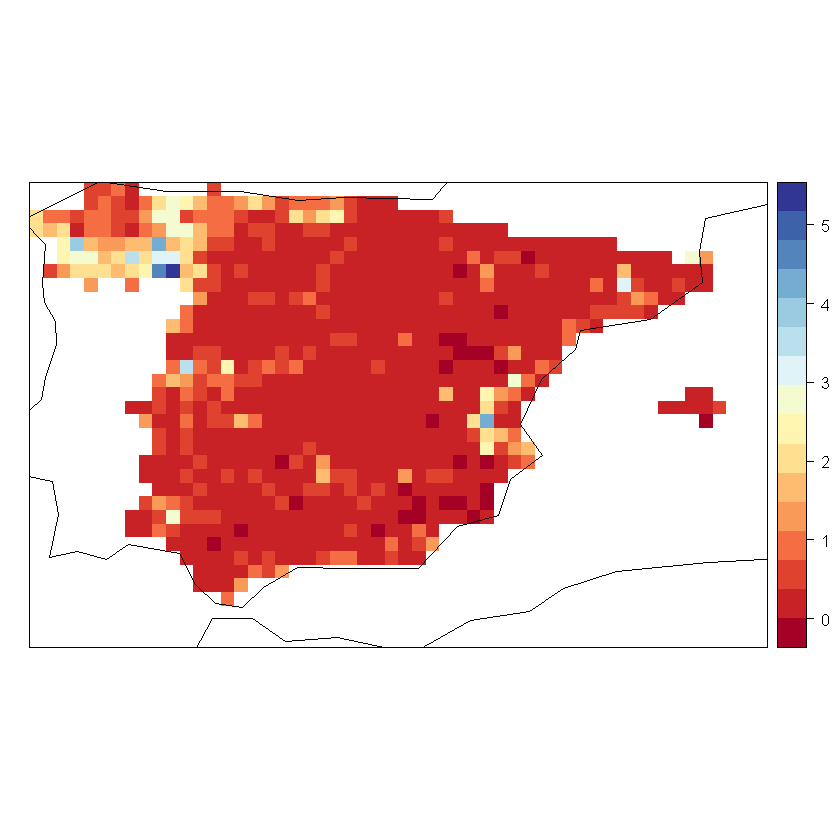

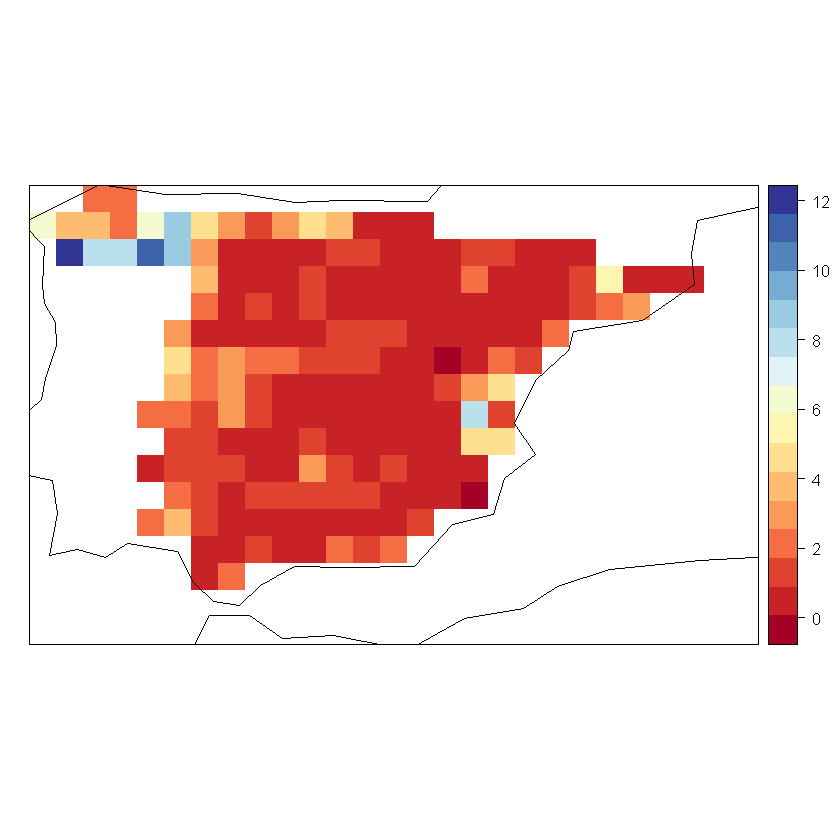

In [6]:
spatialPlot(climatology(ba_grid_025_agg), backdrop.theme = 'coastline')
spatialPlot(climatology(ba_grid_05_agg), backdrop.theme = 'coastline')

In [ ]:
unlink(temp_nc)